<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   HF      120 non-null    int64  
 1   EF      120 non-null    float64
 2   GLS     120 non-null    float64
 3   QRS     120 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.9 KB
HF     0
EF     0
GLS    0
QRS    0
dtype: int64
HF
0    0.5
1    0.5
Name: proportion, dtype: float64
Training samples: 96
Testing samples: 24
Random Forest Accuracy: 0.9583333333333334
              precision    recall  f1-score   support

           0       1.00      0.92      0.96        12
           1       0.92      1.00      0.96        12

    accuracy                           0.96        24
   macro avg       0.96      0.96      0.96        24
weighted avg       0.96      0.96      0.96        24

Cross-validated accuracy scores: [1.         0.91666667 1.         1.         0.91666667 0.91666667
 1.       

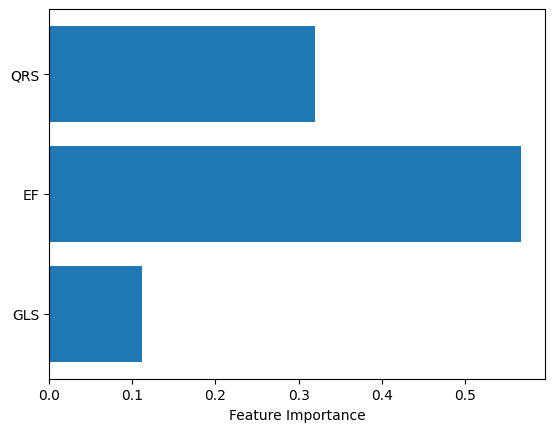

Training Accuracy: 0.9896
Testing Accuracy: 0.9583
Training Error: 0.0104
Testing Error: 0.0417
No obvious overfitting detected.


In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv("heart_failure_data.csv")

# Show the first few rows
df.head(10)

# Check dataset information
df.info()

# Check for missing values
print(df.isnull().sum())

# Merge 1 and 2 into a single class
df['HF'] = df['HF'].apply(lambda x: 1 if x in [1, 2] else 0)

# Separate features and target variable
X = df[['EF','QRS']]  # Features
y = df['HF'] # Target

# Print HF
print(df['HF'].value_counts(normalize=True))

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Train a Random Forest model
model = RandomForestClassifier(n_estimators=100, max_features= 'log2' , min_samples_split=10, random_state=42)
model.fit(X_train, y_train)

# Predict on test data
y_pred = model.predict(X_test)
y_pred_train=model.predict(X_train)

# Evaluate accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Random Forest Accuracy:", accuracy)

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=10)  # 10-fold cross-validation
print("Cross-validated accuracy scores:", scores)
print("Mean CV accuracy:", scores.mean())


import matplotlib.pyplot as plt

importances = model.feature_importances_
features = X.columns
plt.barh(features, importances)
plt.xlabel("Feature Importance")
plt.show()

from sklearn.metrics import accuracy_score

# Calculate training accuracy
accuracy_train = accuracy_score(y_train, y_pred_train)

# Calculate testing accuracy
accuracy_test = accuracy_score(y_test, y_pred)

# Calculate training error
error_train = 1 - accuracy_train

# Calculate testing error
error_test = 1 - accuracy_test

# Print the results
print("Training Accuracy: {:.4f}".format(accuracy_train))
print("Testing Accuracy: {:.4f}".format(accuracy_test))
print("Training Error: {:.4f}".format(error_train))
print("Testing Error: {:.4f}".format(error_test))

# Check if overfitting may be present
if accuracy_train == 1.0 and accuracy_test < 1.0:
    print("Warning: Overfitting detected! Your model performs perfectly on the training data but not on the testing data.")
else:
    print("No obvious overfitting detected.")